# 03_tstr — Comparativa de Escenarios de Augmentacion
## LSTM-VAE: Real Only vs Synthetic Only vs Real + Synthetic
## Dataset evaluacion: SWaT A12 (Mar 2026)

### Objetivo

Evaluar el impacto de la augmentacion con datos sinteticos del TimeGAN v18
sobre la capacidad de deteccion de anomalias del LSTM-VAE. Se comparan
tres escenarios de entrenamiento bajo el mismo protocolo de evaluacion.

### Escenarios

| Escenario | Datos de entrenamiento | Hipotesis |
|---|---|---|
| **real_only** | A12 real normal (3,063 ventanas) | Baseline de referencia |
| **synthetic_only** | Sinteticos TimeGAN (n_synth ventanas) | El GAN genera suficiente variabilidad para entrenar solo |
| **real_plus_synthetic** | A12 real + sinteticos | La augmentacion mejora el baseline |

### Protocolo de evaluacion (identico en los 3 escenarios)

- CSV completo A12 con ataques etiquetados.
- Exclusion de IDs sigilosos 1.0 y 2.0.
- Filtro consecutivo k=3.
- Sweep de tau independiente por escenario (800 puntos).
- Val: A12 normal (20% cronologico) — igual que baseline_v1.

### Rutas de entrada

```
models/detectors/lstm_vae_a12_baseline_v1/   <- scaler, columnas, hiperparams
models/timegan/lstm_vae_a12_baseline_v1_v18/ <- X_synth_cont.npy, X_synth_disc.npy
```


## 0. Imports

In [1]:
import json, joblib, random, gc
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch, torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve
)
import warnings; warnings.filterwarnings('ignore')


In [2]:
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)


Device: cuda


## 1. Rutas y parametros

In [3]:
current_dir  = Path.cwd()
PROJECT_ROOT = current_dir if (current_dir / 'data').exists() else current_dir.parent

RAW_CSV      = PROJECT_ROOT / 'data' / 'clean' / 'SWaT.A12_OTDataset_Mar_26' / '11-Mar-2026_0900_1700_labeled.csv'
OPTUNA_CFG   = PROJECT_ROOT / 'models' / 'detectors' / 'lstm_vae_a12_optuna_v1' / 'optuna_best_config.json'
BASELINE_DIR = PROJECT_ROOT / 'models' / 'detectors' / 'lstm_vae_a12_baseline_v1'
SYNTH_DIR    = PROJECT_ROOT / 'models' / 'timegan'   / 'lstm_vae_a12_baseline_v1_v19_a12only'
TSTR_DIR     = PROJECT_ROOT / 'models' / 'detectors' / 'lstm_vae_tstr'
TSTR_DIR.mkdir(parents=True, exist_ok=True)

print('RAW_CSV     :', RAW_CSV.exists())
print('OPTUNA_CFG  :', OPTUNA_CFG.exists())
print('BASELINE_DIR:', BASELINE_DIR.exists())
print('SYNTH_DIR   :', SYNTH_DIR.exists())
print('TSTR_DIR    :', TSTR_DIR)


RAW_CSV     : True
OPTUNA_CFG  : True
BASELINE_DIR: True
SYNTH_DIR   : True
TSTR_DIR    : d:\Documentos\Uniandes\12 Semestre\PROYECTO DE GRADO\repoPrincipal\ics-synthetic-data-augmentation\models\detectors\lstm_vae_tstr


In [4]:
# Hiperparametros — identicos al baseline_v1
with open(OPTUNA_CFG) as f:
    optuna_cfg = json.load(f)

continuous_cols = optuna_cfg['continuous_cols']
discrete_cols   = optuna_cfg['discrete_cols']
feature_cols    = optuna_cfg['feature_cols']
bp              = optuna_cfg['best_params']

WINDOW_SIZE = int(optuna_cfg['window_size'])
STRIDE      = int(optuna_cfg['stride'])
HIDDEN_SIZE = int(bp['hidden_size'])
NUM_LAYERS  = int(bp['num_layers'])
LATENT_DIM  = int(bp['latent_dim'])
DISC_HIDDEN = int(optuna_cfg['disc_hidden'])
BETA        = float(bp['beta'])
ALPHA       = float(bp['alpha'])
DROPOUT     = float(bp['dropout'])
LR          = float(bp['lr'])
BATCH_SIZE  = int(bp['batch_size'])
CLIP_VAL    = float(optuna_cfg['clip_val'])
MAX_EPOCHS  = 150
PATIENCE    = 20
EXCLUDED_IDS= [1.0, 2.0]
CONSEC_K    = 3
WARMUP      = 120

print(f'Arquitectura : hidden={HIDDEN_SIZE} | layers={NUM_LAYERS} | latent={LATENT_DIM}')
print(f'Entrenamiento: beta={BETA:.4f} | alpha={ALPHA:.4f} | lr={LR:.2e} | batch={BATCH_SIZE}')
print(f'Pipeline     : window={WINDOW_SIZE} | stride={STRIDE} | clip={CLIP_VAL}')


Arquitectura : hidden=192 | layers=1 | latent=96
Entrenamiento: beta=0.0161 | alpha=0.8891 | lr=1.07e-04 | batch=64
Pipeline     : window=60 | stride=10 | clip=5.0


## 2. Carga de datos reales (A12)

Identico al baseline_v1 — scaler cargado desde `baseline_v1/`.

In [5]:
df_raw = pd.read_csv(RAW_CSV, low_memory=False)
df_raw['t_stamp']      = pd.to_datetime(df_raw['t_stamp'], errors='coerce')
df_raw['attack_label'] = pd.to_numeric(df_raw['attack_label'], errors='coerce').fillna(0).astype(int)
df_raw = df_raw.sort_values('t_stamp').reset_index(drop=True)
for col in feature_cols:
    df_raw[col] = pd.to_numeric(df_raw[col].replace('Bad Input', np.nan), errors='coerce')

meta_cols_avail = [c for c in ['attack_id','attack_name','attack_targets'] if c in df_raw.columns]
df_meta = df_raw[['t_stamp','attack_label'] + meta_cols_avail].copy()
df_all  = df_raw[['t_stamp','attack_label'] + feature_cols].copy()

df_work = df_all[df_all['attack_label']==0][['t_stamp']+feature_cols].copy()
df_work = df_work[df_work['t_stamp'] >= df_work['t_stamp'].min() + pd.Timedelta(seconds=WARMUP)]
df_work = df_work.reset_index(drop=True)

n        = len(df_work)
df_train = df_work.iloc[:int(n*0.60)].copy().reset_index(drop=True)
df_val   = df_work.iloc[int(n*0.60):int(n*0.80)].copy().reset_index(drop=True)
df_test  = df_work.iloc[int(n*0.80):].copy().reset_index(drop=True)

modes_train = df_train[feature_cols].mode().iloc[0]
for df_ in [df_train, df_val, df_test]:
    df_[feature_cols] = df_[feature_cols].fillna(modes_train)

# Scaler del baseline_v1 (fiteado sobre A12 train)
scaler_cont = joblib.load(BASELINE_DIR / 'scaler_cont.pkl')
disc_max    = pd.Series(joblib.load(BASELINE_DIR / 'disc_max_dict.pkl'))

def scale_df(df):
    df = df.copy()
    df[continuous_cols] = np.clip(
        scaler_cont.transform(df[continuous_cols].values), -CLIP_VAL, CLIP_VAL
    )
    df[discrete_cols] = (df[discrete_cols] / disc_max).clip(0, 1)
    return df

df_train_sc = scale_df(df_train)
df_val_sc   = scale_df(df_val)
df_test_sc  = scale_df(df_test)

print(f'Normal: {len(df_work):,} | Train: {len(df_train):,} | Val: {len(df_val):,} | Test: {len(df_test):,}')
print(f'Scaler cargado desde: {BASELINE_DIR / "scaler_cont.pkl"}')


Normal: 25,620 | Train: 15,372 | Val: 5,124 | Test: 5,124
Scaler cargado desde: d:\Documentos\Uniandes\12 Semestre\PROYECTO DE GRADO\repoPrincipal\ics-synthetic-data-augmentation\models\detectors\lstm_vae_a12_baseline_v1\scaler_cont.pkl


## 3. Ventanas reales y sinteticas

Se construyen ventanas reales y se cargan los sinteticos del GAN.
Los sinteticos ya estan en formato `(N, T, C)` y escalados con el
mismo scaler — no requieren ninguna transformacion adicional.

In [6]:
def create_windows(arr, ws, stride):
    wins = [arr[i:i+ws] for i in range(0, len(arr)-ws+1, stride)]
    return np.array(wins, dtype=np.float32) if wins \
           else np.empty((0, ws, arr.shape[1]), dtype=np.float32)

def summarize_discrete_windows(disc_windows, dcols):
    rows = []
    for w in disc_windows:
        feats = {}
        for j, col in enumerate(dcols):
            v = w[:, j]; s = pd.Series(v)
            feats[f'{col}__mode']        = s.mode().iloc[0] if len(s.mode()) > 0 else 0.0
            feats[f'{col}__transitions'] = float(np.sum(v[1:] != v[:-1]))
            feats[f'{col}__nunique']     = float(len(np.unique(v)))
            feats[f'{col}__dominance']   = float(s.value_counts(normalize=True).iloc[0])
        rows.append(feats)
    return pd.DataFrame(rows)

def build_windows(df_sc, ws, stride):
    wc  = create_windows(df_sc[continuous_cols].values.astype(np.float32), ws, stride)
    wd  = create_windows(df_sc[discrete_cols].values.astype(np.float32),   ws, stride)
    wds = summarize_discrete_windows(wd, discrete_cols).values.astype(np.float32)
    return wc, wds

# Ventanas reales
X_real_tr_c, X_real_tr_d = build_windows(df_train_sc, WINDOW_SIZE, STRIDE)
X_va_c,      X_va_d      = build_windows(df_val_sc,   WINDOW_SIZE, STRIDE)

# Sinteticos del GAN (ya en (N,T,C), ya escalados)
X_synth_cont = np.load(SYNTH_DIR / 'X_synth_cont.npy').astype(np.float32)  # (N, T, C)
X_synth_disc = np.load(SYNTH_DIR / 'X_synth_disc.npy').astype(np.float32)  # (N, disc_dim)

print(f'Ventanas reales train : {X_real_tr_c.shape}')
print(f'Val                   : {X_va_c.shape}')
print(f'Sinteticos cont       : {X_synth_cont.shape}  <- (N, T, C) OK')
print(f'Sinteticos disc       : {X_synth_disc.shape}')
print()

# Verificar compatibilidad dimensional
assert X_real_tr_c.shape[1:] == X_synth_cont.shape[1:], \
    f"Shape mismatch: real {X_real_tr_c.shape[1:]} vs synth {X_synth_cont.shape[1:]}"
assert X_real_tr_d.shape[1]  == X_synth_disc.shape[1], \
    f"Disc dim mismatch: real {X_real_tr_d.shape[1]} vs synth {X_synth_disc.shape[1]}"
print('Verificacion de dimensiones: OK')

# Estadisticas de comparacion real vs sintetico en espacio escalado
print()
print('Estadisticas espacio escalado (continuas):')
print(f'  Real  — media:{X_real_tr_c.mean():.4f}  std:{X_real_tr_c.std():.4f}  '
      f'min:{X_real_tr_c.min():.2f}  max:{X_real_tr_c.max():.2f}')
print(f'  Synth — media:{X_synth_cont.mean():.4f}  std:{X_synth_cont.std():.4f}  '
      f'min:{X_synth_cont.min():.2f}  max:{X_synth_cont.max():.2f}')


Ventanas reales train : (1532, 60, 31)
Val                   : (507, 60, 31)
Sinteticos cont       : (1532, 60, 31)  <- (N, T, C) OK
Sinteticos disc       : (1532, 124)

Verificacion de dimensiones: OK

Estadisticas espacio escalado (continuas):
  Real  — media:0.0087  std:0.8853  min:-5.00  max:5.00
  Synth — media:0.0365  std:0.9321  min:-6.66  max:71.58


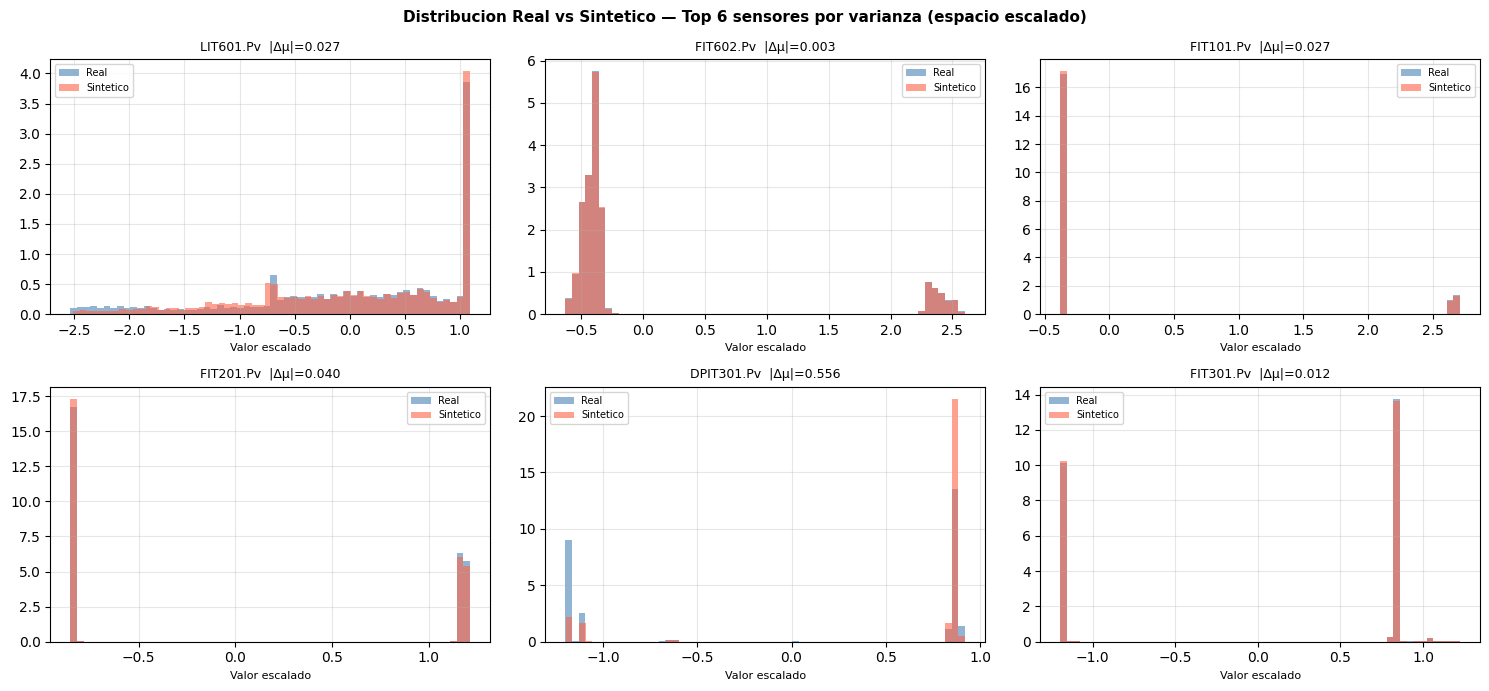

In [7]:
# Comparativa visual de distribuciones reales vs sinteticas
# Top 6 sensores continuos por varianza
var_real = X_real_tr_c.reshape(-1, X_real_tr_c.shape[2]).var(axis=0)
top6_idx = np.argsort(var_real)[-6:][::-1]
top6_names = [continuous_cols[i] for i in top6_idx]

real_flat  = X_real_tr_c.reshape(-1, X_real_tr_c.shape[2])
synth_flat = X_synth_cont.reshape(-1, X_synth_cont.shape[2])

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, idx, name in zip(axes.flat, top6_idx, top6_names):
    ax.hist(real_flat[:, idx],  bins=60, alpha=0.6, density=True,
            color='steelblue', label='Real', edgecolor='none')
    ax.hist(synth_flat[:, idx], bins=60, alpha=0.6, density=True,
            color='tomato',    label='Sintetico', edgecolor='none')
    dm = abs(real_flat[:,idx].mean() - synth_flat[:,idx].mean())
    ax.set_title(f'{name}  |Δμ|={dm:.3f}', fontsize=9)
    ax.set_xlabel('Valor escalado', fontsize=8)
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

plt.suptitle('Distribucion Real vs Sintetico — Top 6 sensores por varianza (espacio escalado)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(str(TSTR_DIR / 'dist_real_vs_synth.png'), dpi=120, bbox_inches='tight')
plt.show()


## 4. Arquitectura y funciones compartidas

El modelo y las funciones de evaluacion son identicos en los 3 escenarios.
Solo cambia el `DataLoader` de entrenamiento.

In [8]:
class LSTMEncoder(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, latent_dim, dropout):
        super().__init__()
        self.lstm      = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True,
                                  dropout=dropout if num_layers > 1 else 0.0)
        self.drop      = nn.Dropout(dropout)
        self.fc_mu     = nn.Linear(hidden_size, latent_dim)
        self.fc_logvar = nn.Linear(hidden_size, latent_dim)
    def forward(self, x):
        _, (h, _) = self.lstm(x)
        h_last = self.drop(h[-1])
        return self.fc_mu(h_last), self.fc_logvar(h_last)

class LSTMDecoder(nn.Module):
    def __init__(self, latent_dim, hidden_size, num_layers, output_size, seq_len, dropout):
        super().__init__()
        self.seq_len    = seq_len
        self.num_layers = num_layers
        self.fc_h0      = nn.Linear(latent_dim, hidden_size)
        self.lstm       = nn.LSTM(latent_dim, hidden_size, num_layers, batch_first=True,
                                   dropout=dropout if num_layers > 1 else 0.0)
        self.drop       = nn.Dropout(dropout)
        self.fc_out     = nn.Linear(hidden_size, output_size)
    def forward(self, z):
        h0 = torch.tanh(self.fc_h0(z)).unsqueeze(0).repeat(self.num_layers, 1, 1)
        c0 = torch.zeros_like(h0)
        out, _ = self.lstm(z.unsqueeze(1).repeat(1, self.seq_len, 1), (h0, c0))
        return self.fc_out(self.drop(out))

class HybridLSTMVAE(nn.Module):
    def __init__(self, cont_size, seq_len, disc_dim,
                 hidden_size=128, num_layers=2, latent_dim=64, disc_hidden=64, dropout=0.2):
        super().__init__()
        self.encoder_cont = LSTMEncoder(cont_size, hidden_size, num_layers, latent_dim, dropout)
        self.decoder_cont = LSTMDecoder(latent_dim, hidden_size, num_layers, cont_size, seq_len, dropout)
        self.encoder_disc = nn.Sequential(
            nn.Linear(disc_dim, disc_hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(disc_hidden, disc_hidden // 2), nn.ReLU())
        self.decoder_disc = nn.Sequential(
            nn.Linear(disc_hidden // 2, disc_hidden), nn.ReLU(),
            nn.Linear(disc_hidden, disc_dim))
    def reparameterize(self, mu, logvar):
        if self.training:
            return mu + torch.randn_like(mu) * torch.exp(0.5 * logvar)
        return mu
    def forward(self, xc, xd):
        mu, logvar = self.encoder_cont(xc)
        z = self.reparameterize(mu, logvar)
        return self.decoder_cont(z), self.decoder_disc(self.encoder_disc(xd)), mu, logvar

def elbo_loss(xc, xc_hat, xd, xd_hat, mu, logvar, alpha, beta):
    mse_c = nn.functional.mse_loss(xc_hat, xc)
    mse_d = nn.functional.mse_loss(xd_hat, xd)
    kl    = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    return alpha * (mse_c + beta * kl) + (1 - alpha) * mse_d, mse_c, mse_d, kl

def build_model():
    return HybridLSTMVAE(
        cont_size   = len(continuous_cols),
        seq_len     = WINDOW_SIZE,
        disc_dim    = X_real_tr_d.shape[1],
        hidden_size = HIDDEN_SIZE,
        num_layers  = NUM_LAYERS,
        latent_dim  = LATENT_DIM,
        disc_hidden = DISC_HIDDEN,
        dropout     = DROPOUT
    ).to(device)

print(f'Arquitectura instanciada correctamente.')
print(f'Parametros: {sum(p.numel() for p in build_model().parameters()):,}')


Arquitectura instanciada correctamente.
Parametros: 477,435


In [9]:
def train_model(Xc_train, Xd_train, label):
    """Entrena un LSTM-VAE desde cero con los datos dados.
    Usa el val set de A12 real en todos los escenarios.
    Retorna el modelo en modo eval con los mejores pesos.
    """
    torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)
    model = build_model()
    train_loader = DataLoader(
        TensorDataset(torch.tensor(Xc_train, dtype=torch.float32),
                      torch.tensor(Xd_train, dtype=torch.float32)),
        batch_size=BATCH_SIZE, shuffle=True, drop_last=True
    )
    val_loader = DataLoader(
        TensorDataset(torch.tensor(X_va_c, dtype=torch.float32),
                      torch.tensor(X_va_d, dtype=torch.float32)),
        batch_size=BATCH_SIZE, shuffle=False
    )
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=10, min_lr=1e-6
    )
    best_val, best_wts, no_improve, best_ep = float('inf'), None, 0, 1
    train_hist, val_hist = [], []

    print(f'\n[{label}] Entrenando — {len(Xc_train):,} ventanas train | '
          f'{len(X_va_c):,} val | batch={BATCH_SIZE} | max_ep={MAX_EPOCHS}')

    for epoch in range(1, MAX_EPOCHS + 1):
        model.train()
        tl = 0.0
        for xc, xd in train_loader:
            xc, xd = xc.to(device), xd.to(device)
            optimizer.zero_grad()
            xc_hat, xd_hat, mu, logvar = model(xc, xd)
            loss = elbo_loss(xc, xc_hat, xd, xd_hat, mu, logvar, ALPHA, BETA)[0]
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()
            tl += loss.item()
        tl /= len(train_loader)

        model.eval()
        vl = 0.0
        with torch.no_grad():
            for xc, xd in val_loader:
                xc, xd = xc.to(device), xd.to(device)
                xc_hat, xd_hat, mu, logvar = model(xc, xd)
                vl += elbo_loss(xc, xc_hat, xd, xd_hat, mu, logvar, ALPHA, BETA)[0].item()
        vl /= len(val_loader)
        scheduler.step(vl)
        train_hist.append(tl); val_hist.append(vl)

        if vl < best_val - 1e-6:
            best_val = vl
            best_wts = {k: v.clone() for k, v in model.state_dict().items()}
            best_ep  = epoch; no_improve = 0
        else:
            no_improve += 1

        if epoch % 20 == 0:
            print(f'  Ep {epoch:4d}/{MAX_EPOCHS} | Train:{tl:.5f} | Val:{vl:.5f} | Best:{best_val:.5f}(ep{best_ep})')
        if no_improve >= PATIENCE:
            print(f'  Early stop ep{epoch}.')
            break

    model.load_state_dict(best_wts)
    model.eval()
    print(f'  Mejor val: {best_val:.5f} ep{best_ep}')
    return model, train_hist, val_hist, best_ep, best_val


def recon_scores(model, Xc, Xd, alpha, bs=256):
    loader = DataLoader(TensorDataset(torch.tensor(Xc, dtype=torch.float32),
                                      torch.tensor(Xd, dtype=torch.float32)),
                        batch_size=bs, shuffle=False)
    ec_l, ed_l = [], []
    model.eval()
    with torch.no_grad():
        for xc, xd in loader:
            xc, xd = xc.to(device), xd.to(device)
            xc_hat, xd_hat, mu, _ = model(xc, xd)
            ec_l.extend(torch.mean((xc_hat-xc)**2, dim=(1,2)).cpu().numpy())
            ed_l.extend(torch.mean((xd_hat-xd)**2, dim=1).cpu().numpy())
    ec = np.array(ec_l); ed = np.array(ed_l)
    return alpha * ec + (1 - alpha) * ed


def consecutive_filter(scores_arr, tau, k):
    raw = (scores_arr > tau).astype(int)
    if k <= 1: return raw
    out = np.zeros_like(raw)
    for i in range(k-1, len(raw)):
        out[i] = int(raw[i-k+1:i+1].all())
    return out


def evaluate_scenario(model, X_eval_c, X_eval_d, df_wins_eval, y_all_eval,
                      excl_ids, consec_k, label, save_dir):
    """Protocolo de evaluacion definitivo para un modelo.
    Retorna dict con todas las metricas y el tau optimo.
    """
    scores = recon_scores(model, X_eval_c, X_eval_d, ALPHA)

    # Referencia global
    auc_ref = roc_auc_score(y_all_eval, scores)
    mn = scores[y_all_eval==0].mean(); ma = scores[y_all_eval==1].mean()

    # Excluir ataques sigilosos
    mask_keep = ~((df_wins_eval['y']==1) & (df_wins_eval['attack_id'].isin(excl_ids)))
    sc_filt   = scores[mask_keep.values]
    y_filt    = df_wins_eval[mask_keep]['y'].values

    # Sweep tau con k consecutivo
    taus = np.percentile(sc_filt, np.linspace(0.5, 99.5, 800))
    best_f1, best_tau = -1, taus[0]
    for tau in taus:
        pred = consecutive_filter(sc_filt, tau, consec_k)
        tp = ((pred==1)&(y_filt==1)).sum(); fp = ((pred==1)&(y_filt==0)).sum()
        fn = ((pred==0)&(y_filt==1)).sum(); tn = ((pred==0)&(y_filt==0)).sum()
        p = tp/(tp+fp+1e-10); r = tp/(tp+fn+1e-10)
        f1 = 2*p*r/(p+r+1e-10)
        if f1 > best_f1: best_f1, best_tau = f1, tau

    # Metricas finales
    pred_f = consecutive_filter(sc_filt, best_tau, consec_k)
    tp = int(((pred_f==1)&(y_filt==1)).sum())
    fp = int(((pred_f==1)&(y_filt==0)).sum())
    fn = int(((pred_f==0)&(y_filt==1)).sum())
    tn = int(((pred_f==0)&(y_filt==0)).sum())
    prec = tp/(tp+fp+1e-10); rec = tp/(tp+fn+1e-10)
    f1   = 2*prec*rec/(prec+rec+1e-10)
    fpr  = fp/(fp+tn+1e-10)
    auc_filt  = roc_auc_score(y_filt, sc_filt)
    pr_auc    = average_precision_score(y_filt, sc_filt)

    result = {
        'label'    : label,
        'tau'      : float(best_tau),
        'roc_auc'  : float(auc_filt),
        'roc_auc_ref': float(auc_ref),
        'pr_auc'   : float(pr_auc),
        'f1'       : float(f1),
        'recall'   : float(rec),
        'precision': float(prec),
        'fpr'      : float(fpr),
        'tp': tp, 'fp': fp, 'fn': fn, 'tn': tn,
        'ratio_atk_norm': float(ma/mn) if mn > 0 else 0,
        'scores_all': scores,
        'sc_filt'  : sc_filt,
        'y_filt'   : y_filt,
        'mask_keep': mask_keep.values,
    }
    print(f'  [{label}] AUC={auc_filt:.4f} | F1={f1:.3f} | '
          f'Rec={rec:.3f} | Prec={prec:.3f} | FPR={fpr:.3f} | tau={best_tau:.4f}')
    return result

print('Funciones definidas: train_model, recon_scores, consecutive_filter, evaluate_scenario')


Funciones definidas: train_model, recon_scores, consecutive_filter, evaluate_scenario


## 5. Construccion de ventanas de evaluacion (A12 completo)

In [10]:
df_eval_sc = df_all[['t_stamp','attack_label'] + feature_cols].copy()
df_eval_sc[feature_cols]    = df_eval_sc[feature_cols].fillna(modes_train)
df_eval_sc[continuous_cols] = np.clip(
    scaler_cont.transform(df_eval_sc[continuous_cols].values), -CLIP_VAL, CLIP_VAL
)
df_eval_sc[discrete_cols] = (df_eval_sc[discrete_cols] / disc_max).clip(0, 1)

cont_arr   = df_eval_sc[continuous_cols].values.astype(np.float32)
disc_arr   = df_eval_sc[discrete_cols].values.astype(np.float32)
labs_arr   = df_eval_sc['attack_label'].values
tstamp_arr = df_eval_sc['t_stamp'].values
aid_arr    = df_meta['attack_id'].values   if 'attack_id'   in df_meta.columns else np.zeros(len(df_meta))
aname_arr  = df_meta['attack_name'].values if 'attack_name' in df_meta.columns else np.full(len(df_meta),'unknown')

wins_c, wins_d, meta_rows = [], [], []
for s in range(0, len(cont_arr) - WINDOW_SIZE + 1, STRIDE):
    wins_c.append(cont_arr[s:s+WINDOW_SIZE])
    wins_d.append(disc_arr[s:s+WINDOW_SIZE])
    seg_labs = labs_arr[s:s+WINDOW_SIZE]
    seg_aids = aid_arr[s:s+WINDOW_SIZE]
    seg_anms = aname_arr[s:s+WINDOW_SIZE]
    atk_ids  = seg_aids[seg_labs==1]
    atk_nms  = seg_anms[seg_labs==1]
    if len(atk_ids) > 0:
        uid,cnt = np.unique(atk_ids, return_counts=True); aid_mode = uid[cnt.argmax()]
        unm,cnm = np.unique(atk_nms, return_counts=True); anm_mode = unm[cnm.argmax()]
    else:
        aid_mode, anm_mode = 0, 'normal'
    meta_rows.append({'y': int(np.any(seg_labs==1)), 'attack_id': aid_mode,
                      'attack_name': str(anm_mode), 't_start': tstamp_arr[s],
                      'attack_frac': float(np.mean(seg_labs==1))})

X_eval_c = np.array(wins_c, dtype=np.float32)
X_eval_d = summarize_discrete_windows(
    np.array(wins_d, dtype=np.float32), discrete_cols).values.astype(np.float32)
df_wins  = pd.DataFrame(meta_rows)
y_all    = df_wins['y'].values

print(f'Ventanas eval: {len(df_wins):,} | Normal: {(y_all==0).sum():,} | Ataque: {(y_all==1).sum():,}')


Ventanas eval: 2,881 | Normal: 2,519 | Ataque: 362


## 6. Escenario 1 — real_only

Entrenamiento solo con datos reales de A12 normal.
Este es el baseline de referencia — deberia reproducir los resultados
del notebook `02b_lstm_vae_a12_baseline_v1`.

In [11]:
model_real, hist_tr_real, hist_va_real, ep_real, val_real = train_model(
    X_real_tr_c, X_real_tr_d, 'real_only'
)
torch.save(model_real.state_dict(), TSTR_DIR / 'model_real_only.pt')



[real_only] Entrenando — 1,532 ventanas train | 507 val | batch=64 | max_ep=150
  Ep   20/150 | Train:0.15894 | Val:0.39654 | Best:0.39654(ep20)
  Ep   40/150 | Train:0.09433 | Val:0.35076 | Best:0.34851(ep36)
  Ep   60/150 | Train:0.07979 | Val:0.34190 | Best:0.34190(ep60)
  Ep   80/150 | Train:0.07268 | Val:0.35246 | Best:0.34190(ep60)
  Early stop ep80.
  Mejor val: 0.34190 ep60


## 7. Escenario 2 — synthetic_only

Entrenamiento exclusivamente con sinteticos del TimeGAN.
El val set es siempre A12 real (no podemos evaluar convergencia
con sinteticos porque no tienen etiquetas de ataque).

Si `n_synth` es muy distinto de `n_real_train`, el modelo ve una
cantidad muy diferente de ventanas — parte de la comparativa.

In [12]:
model_synth, hist_tr_synth, hist_va_synth, ep_synth, val_synth = train_model(
    X_synth_cont, X_synth_disc, 'synthetic_only'
)
torch.save(model_synth.state_dict(), TSTR_DIR / 'model_synthetic_only.pt')



[synthetic_only] Entrenando — 1,532 ventanas train | 507 val | batch=64 | max_ep=150
  Ep   20/150 | Train:0.66805 | Val:0.46811 | Best:0.46811(ep20)
  Ep   40/150 | Train:0.50037 | Val:0.41780 | Best:0.41780(ep40)
  Ep   60/150 | Train:0.44499 | Val:0.36769 | Best:0.36682(ep59)
  Ep   80/150 | Train:0.42566 | Val:0.36150 | Best:0.35977(ep79)
  Ep  100/150 | Train:0.37981 | Val:0.35883 | Best:0.35578(ep97)
  Ep  120/150 | Train:0.40411 | Val:0.35461 | Best:0.35245(ep117)
  Ep  140/150 | Train:0.39667 | Val:0.35122 | Best:0.34975(ep138)
  Mejor val: 0.34813 ep150


## 8. Escenario 3 — real_plus_synthetic

Entrenamiento con datos reales A12 + sinteticos concatenados.
El numero total de ventanas es `n_real_train + n_synth`.

In [13]:
X_combined_c = np.concatenate([X_real_tr_c, X_synth_cont], axis=0)
X_combined_d = np.concatenate([X_real_tr_d, X_synth_disc], axis=0)

print(f'Combined train: {X_combined_c.shape[0]:,} ventanas '
      f'(real={len(X_real_tr_c):,} + synth={len(X_synth_cont):,})')
print(f'Proporcion real: {100*len(X_real_tr_c)/len(X_combined_c):.1f}%')

model_comb, hist_tr_comb, hist_va_comb, ep_comb, val_comb = train_model(
    X_combined_c, X_combined_d, 'real_plus_synthetic'
)
torch.save(model_comb.state_dict(), TSTR_DIR / 'model_real_plus_synthetic.pt')


Combined train: 3,064 ventanas (real=1,532 + synth=1,532)
Proporcion real: 50.0%

[real_plus_synthetic] Entrenando — 3,064 ventanas train | 507 val | batch=64 | max_ep=150
  Ep   20/150 | Train:0.35627 | Val:0.29671 | Best:0.29671(ep20)
  Ep   40/150 | Train:0.29491 | Val:0.25594 | Best:0.25351(ep39)
  Ep   60/150 | Train:0.26561 | Val:0.24409 | Best:0.24316(ep56)
  Ep   80/150 | Train:0.25309 | Val:0.24106 | Best:0.24106(ep80)
  Ep  100/150 | Train:0.25006 | Val:0.24227 | Best:0.24047(ep83)
  Early stop ep103.
  Mejor val: 0.24047 ep83


## 9. Curvas de entrenamiento comparativas

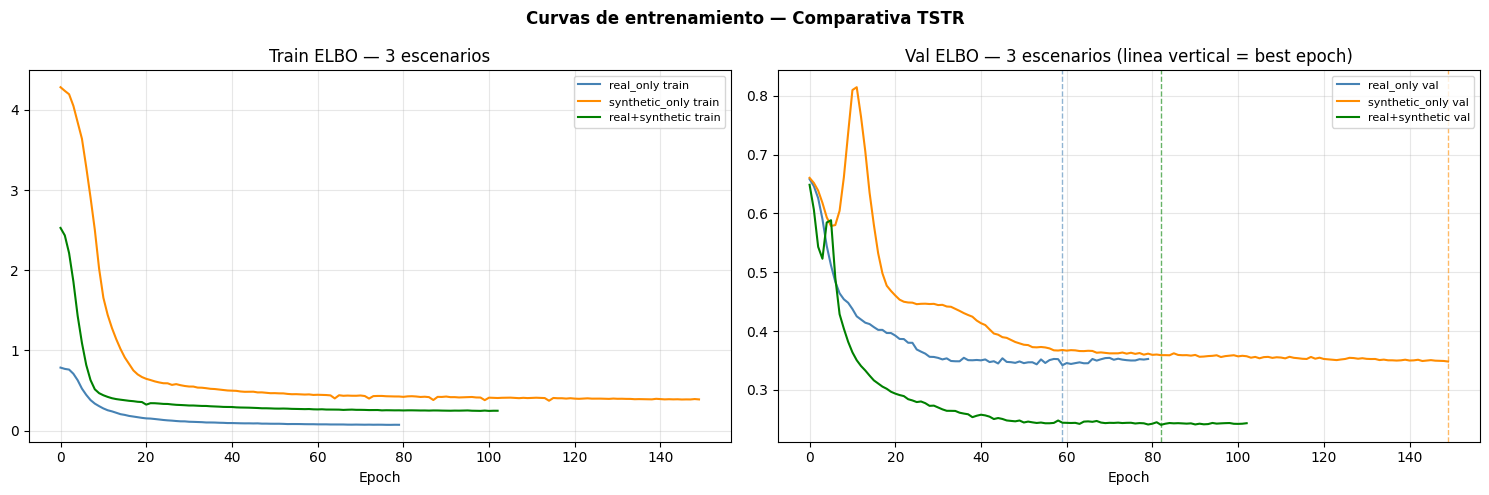

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
scenarios_hist = [
    ('real_only',          hist_tr_real,  hist_va_real,  ep_real,  'steelblue'),
    ('synthetic_only',     hist_tr_synth, hist_va_synth, ep_synth, 'darkorange'),
    ('real+synthetic',     hist_tr_comb,  hist_va_comb,  ep_comb,  'green'),
]
for label, tr, va, ep, col in scenarios_hist:
    axes[0].plot(tr, lw=1.5, color=col, label=f'{label} train')
    axes[1].plot(va, lw=1.5, color=col, label=f'{label} val')
    axes[1].axvline(ep-1, color=col, lw=1, linestyle='--', alpha=0.6)

axes[0].set_title('Train ELBO — 3 escenarios'); axes[0].set_xlabel('Epoch')
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)
axes[1].set_title('Val ELBO — 3 escenarios (linea vertical = best epoch)')
axes[1].set_xlabel('Epoch')
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)

plt.suptitle('Curvas de entrenamiento — Comparativa TSTR', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(str(TSTR_DIR / 'training_curves_comparison.png'), dpi=120, bbox_inches='tight')
plt.show()


## 10. Evaluacion de los 3 escenarios

In [15]:
print('Evaluando los 3 escenarios con protocolo definitivo...')
print(f'(excl. IDs {EXCLUDED_IDS} | k={CONSEC_K} | sweep 800 taus)\n')

results = {}
for model_, label_ in [
    (model_real,  'real_only'),
    (model_synth, 'synthetic_only'),
    (model_comb,  'real_plus_synthetic'),
]:
    results[label_] = evaluate_scenario(
        model_, X_eval_c, X_eval_d, df_wins, y_all,
        EXCLUDED_IDS, CONSEC_K, label_, TSTR_DIR
    )


Evaluando los 3 escenarios con protocolo definitivo...
(excl. IDs [1.0, 2.0] | k=3 | sweep 800 taus)

  [real_only] AUC=0.8751 | F1=0.475 | Rec=0.808 | Prec=0.336 | FPR=0.185 | tau=0.2314
  [synthetic_only] AUC=0.6983 | F1=0.281 | Rec=0.712 | Prec=0.175 | FPR=0.389 | tau=0.2010
  [real_plus_synthetic] AUC=0.8285 | F1=0.413 | Rec=0.613 | Prec=0.312 | FPR=0.157 | tau=0.1410


## 11. Tabla comparativa global

In [16]:
df_comp = pd.DataFrame([
    {
        'Escenario'    : r['label'],
        'Train windows': ({'real_only': len(X_real_tr_c),
                           'synthetic_only': len(X_synth_cont),
                           'real_plus_synthetic': len(X_combined_c)})[r['label']],
        'ROC-AUC'      : round(r['roc_auc'], 4),
        'PR-AUC'       : round(r['pr_auc'], 4),
        'F1'           : round(r['f1'], 3),
        'Recall'       : round(r['recall'], 3),
        'Precision'    : round(r['precision'], 3),
        'FPR'          : round(r['fpr'], 3),
        'TP'           : r['tp'], 'FP': r['fp'],
        'FN'           : r['fn'], 'TN': r['tn'],
        'Ratio atk/norm': round(r['ratio_atk_norm'], 2),
        'Tau optimo'   : round(r['tau'], 4),
    }
    for r in results.values()
])

print('=' * 100)
print('TABLA COMPARATIVA — TSTR (excl. IDs 1.0, 2.0 | k=3 | sweep tau)')
print('=' * 100)
print(df_comp.to_string(index=False))
print()

# Mejora relativa sobre real_only
base = results['real_only']
print('Mejora relativa sobre real_only:')
for key in ['synthetic_only', 'real_plus_synthetic']:
    r = results[key]
    d_auc = r['roc_auc'] - base['roc_auc']
    d_f1  = r['f1']      - base['f1']
    d_rec = r['recall']  - base['recall']
    d_fpr = r['fpr']     - base['fpr']
    print(f'  {key:<25}: ΔAUC={d_auc:+.4f} | ΔF1={d_f1:+.3f} | '
          f'ΔRecall={d_rec:+.3f} | ΔFPR={d_fpr:+.3f}')

df_comp.to_csv(TSTR_DIR / 'tabla_comparativa.csv', index=False)


TABLA COMPARATIVA — TSTR (excl. IDs 1.0, 2.0 | k=3 | sweep tau)
          Escenario  Train windows  ROC-AUC  PR-AUC    F1  Recall  Precision   FPR  TP  FP  FN   TN  Ratio atk/norm  Tau optimo
          real_only           1532   0.8751  0.3138 0.475   0.808      0.336 0.185 236 466  56 2053            2.42      0.2314
     synthetic_only           1532   0.6983  0.1667 0.281   0.712      0.175 0.389 208 981  84 1538            0.83      0.2010
real_plus_synthetic           3064   0.8285  0.2630 0.413   0.613      0.312 0.157 179 395 113 2124            2.08      0.1410

Mejora relativa sobre real_only:
  synthetic_only           : ΔAUC=-0.1768 | ΔF1=-0.194 | ΔRecall=-0.096 | ΔFPR=+0.204
  real_plus_synthetic      : ΔAUC=-0.0466 | ΔF1=-0.061 | ΔRecall=-0.195 | ΔFPR=-0.028


## 12. Graficos comparativos

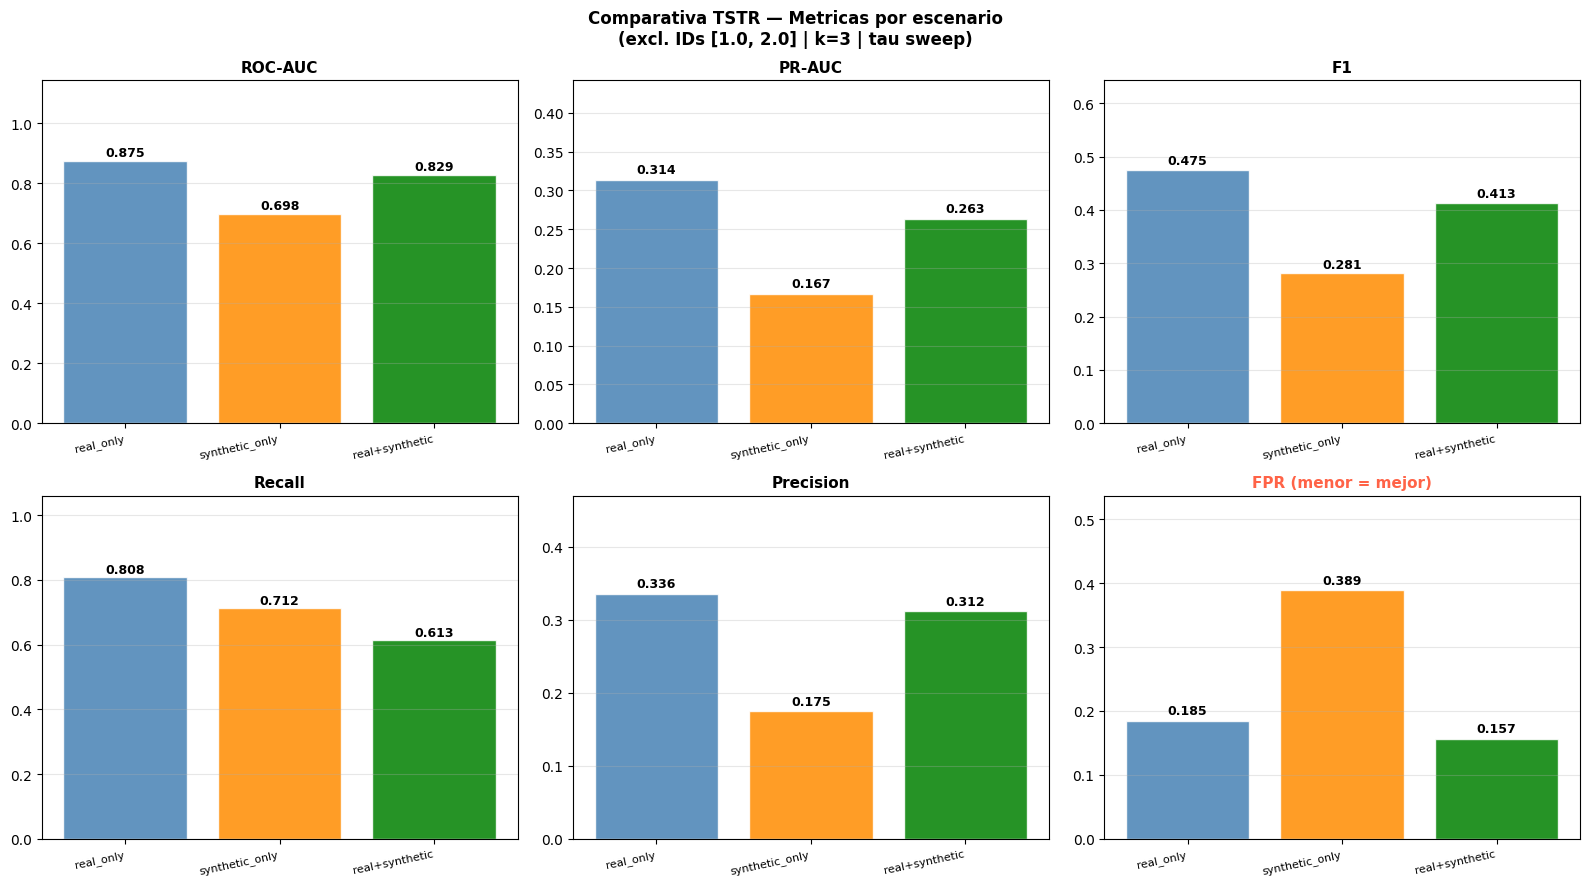

In [17]:
# Barras de metricas
scenario_labels = ['real_only', 'synthetic_only', 'real+synthetic']
colors_sc = ['steelblue', 'darkorange', 'green']
metrics_plot = ['roc_auc', 'pr_auc', 'f1', 'recall', 'precision', 'fpr']
metric_labels = ['ROC-AUC', 'PR-AUC', 'F1', 'Recall', 'Precision', 'FPR']
r_keys = ['real_only', 'synthetic_only', 'real_plus_synthetic']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, met, met_label in zip(axes.flat, metrics_plot, metric_labels):
    vals = [results[k][met] for k in r_keys]
    bars = ax.bar(scenario_labels, vals, color=colors_sc, alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_title(met_label, fontsize=11, fontweight='bold')
    ax.set_ylim(0, min(1.15, max(vals)*1.25 + 0.05))
    ax.set_xticklabels(scenario_labels, rotation=12, ha='right', fontsize=8)
    ax.grid(True, alpha=0.3, axis='y')
    # Linea de referencia FPR bajo = bueno
    if met == 'fpr':
        ax.set_title('FPR (menor = mejor)', fontsize=11, fontweight='bold', color='tomato')

plt.suptitle('Comparativa TSTR — Metricas por escenario\n'
             f'(excl. IDs {EXCLUDED_IDS} | k={CONSEC_K} | tau sweep)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(str(TSTR_DIR / 'metricas_comparativas.png'), dpi=130, bbox_inches='tight')
plt.show()


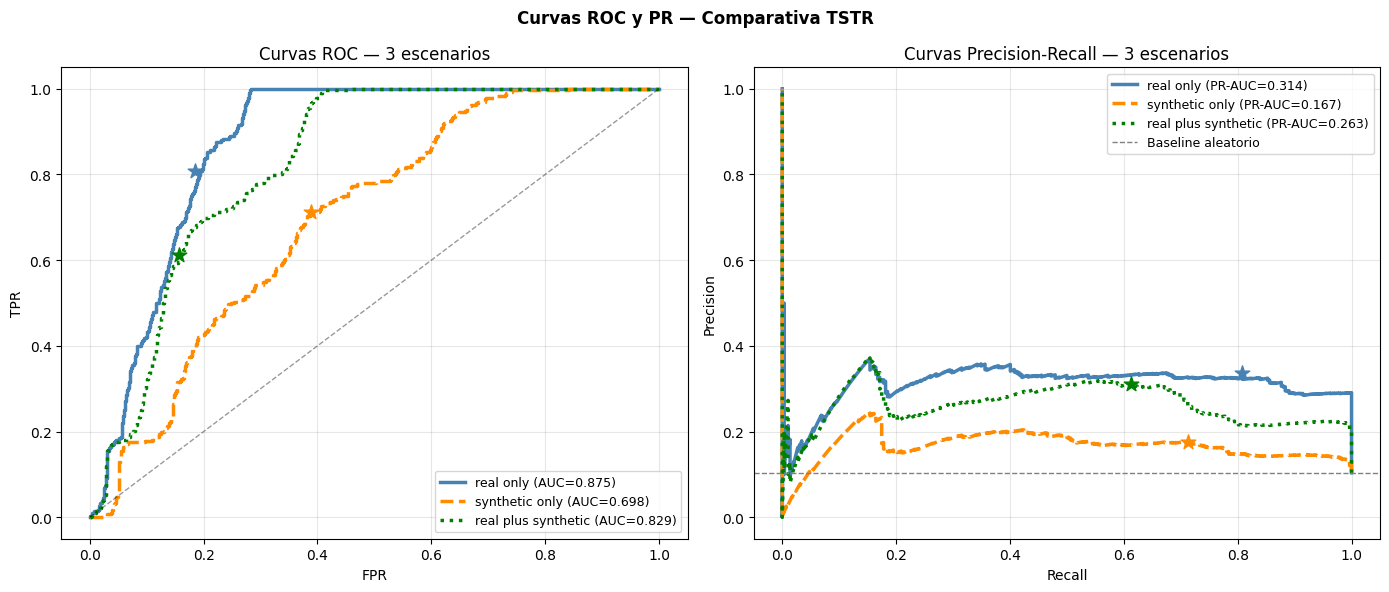

In [18]:
# Curvas ROC y PR superpuestas
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
styles = ['-', '--', ':']

for (key, col, style) in zip(r_keys, colors_sc, styles):
    r = results[key]
    fprs_, tprs_, _ = roc_curve(r['y_filt'], r['sc_filt'])
    precs_, recs_, _ = precision_recall_curve(r['y_filt'], r['sc_filt'])
    lbl = key.replace('_', ' ')

    axes[0].plot(fprs_, tprs_, lw=2.5, color=col, linestyle=style,
                 label=f'{lbl} (AUC={r["roc_auc"]:.3f})')
    axes[0].scatter(r['fpr'], r['recall'], s=120, color=col, zorder=5, marker='*')

    axes[1].plot(recs_, precs_, lw=2.5, color=col, linestyle=style,
                 label=f'{lbl} (PR-AUC={r["pr_auc"]:.3f})')
    axes[1].scatter(r['recall'], r['precision'], s=120, color=col, zorder=5, marker='*')

axes[0].plot([0,1],[0,1],'k--',lw=1,alpha=0.4)
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('Curvas ROC — 3 escenarios')
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)

axes[1].axhline(results['real_only']['y_filt'].mean(),
                color='gray', linestyle='--', lw=1, label='Baseline aleatorio')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Curvas Precision-Recall — 3 escenarios')
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3)

plt.suptitle('Curvas ROC y PR — Comparativa TSTR', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(str(TSTR_DIR / 'roc_pr_comparison.png'), dpi=130, bbox_inches='tight')
plt.show()


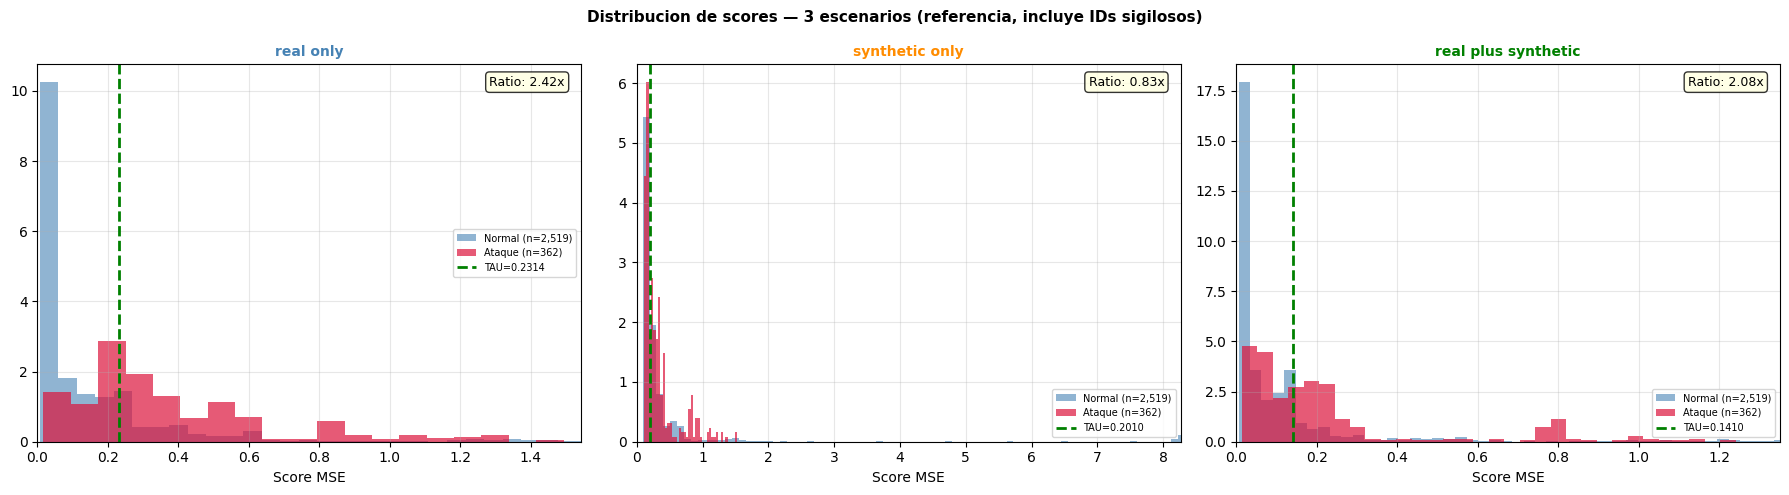

In [19]:
# Distribuciones de scores por escenario
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, key, col in zip(axes, r_keys, colors_sc):
    r = results[key]
    sc = r['scores_all']; y = y_all
    ax.hist(sc[y==0], bins=80, alpha=0.6, density=True, color='steelblue',
            label=f'Normal (n={(y==0).sum():,})')
    ax.hist(sc[y==1], bins=40, alpha=0.7, density=True, color='crimson',
            label=f'Ataque (n={(y==1).sum():,})')
    ax.axvline(r['tau'], color='green', lw=2, linestyle='--', label=f'TAU={r["tau"]:.4f}')
    ratio = r['ratio_atk_norm']
    ax.text(0.97, 0.97, f'Ratio: {ratio:.2f}x', ha='right', va='top',
            transform=ax.transAxes,
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8), fontsize=9)
    ax.set_title(key.replace('_',' '), fontsize=10, fontweight='bold', color=col)
    ax.set_xlabel('Score MSE'); ax.legend(fontsize=7); ax.grid(True, alpha=0.3)
    xlim = np.percentile(sc, 99.5)
    ax.set_xlim(0, xlim)

plt.suptitle('Distribucion de scores — 3 escenarios (referencia, incluye IDs sigilosos)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(str(TSTR_DIR / 'score_distributions.png'), dpi=130, bbox_inches='tight')
plt.show()


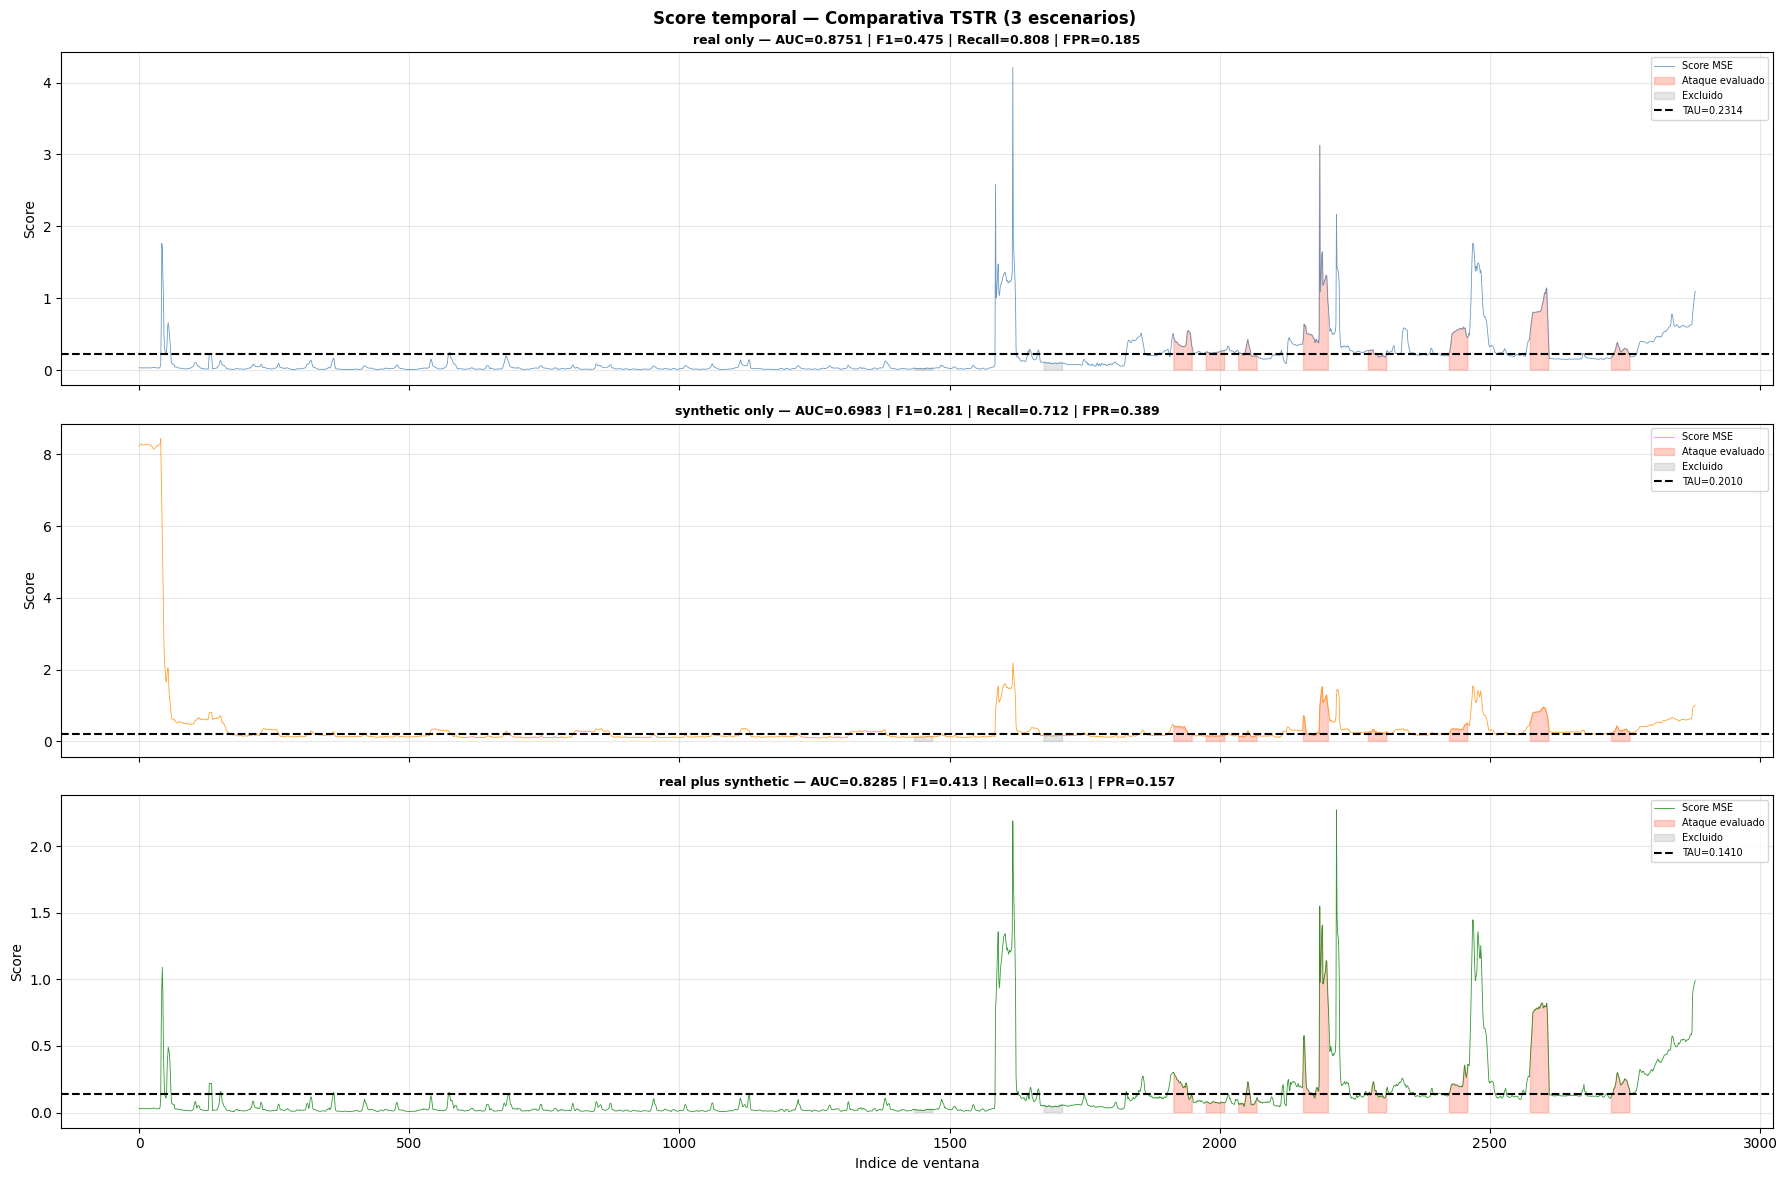

In [20]:
# Score temporal para los 3 escenarios
t = np.arange(len(df_wins))
excl_mask = ((df_wins['y']==1) & (df_wins['attack_id'].isin(EXCLUDED_IDS))).values

fig, axes = plt.subplots(3, 1, figsize=(18, 12), sharex=True)
for ax, key, col in zip(axes, r_keys, colors_sc):
    r = results[key]
    sc = r['scores_all']
    pred_k = consecutive_filter(sc, r['tau'], CONSEC_K)

    ax.plot(t, sc, color=col, lw=0.6, alpha=0.8, label='Score MSE')
    ax.fill_between(t, 0, sc, where=(y_all==1) & ~excl_mask,
                    color='tomato', alpha=0.30, label='Ataque evaluado')
    ax.fill_between(t, 0, sc, where=excl_mask,
                    color='gray', alpha=0.20, label='Excluido')
    ax.axhline(r['tau'], color='black', lw=1.5, linestyle='--',
               label=f'TAU={r["tau"]:.4f}')
    ttl = key.replace('_', ' ')
    ax.set_title(f'{ttl} — AUC={r["roc_auc"]:.4f} | F1={r["f1"]:.3f} | '
                 f'Recall={r["recall"]:.3f} | FPR={r["fpr"]:.3f}',
                 fontsize=9, fontweight='bold')
    ax.set_ylabel('Score'); ax.legend(fontsize=7, loc='upper right'); ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Indice de ventana')
plt.suptitle('Score temporal — Comparativa TSTR (3 escenarios)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(str(TSTR_DIR / 'score_temporal_comparison.png'), dpi=130, bbox_inches='tight')
plt.show()


Deteccion por tipo de ataque (%):
   ID  Nombre                                N     real_only    synth_only    real+synth
--------------------------------------------------------------------------------
    1  Stage 5 Valve Manipulation — M       35          0.0%          0.0%          0.0%  [EXCL]
    2  Stage 1 Flow Disruption — MV10       35          0.0%          0.0%          0.0%  [EXCL]
    3  Florida Water Plant Scenario —       35         94.3%         82.9%         71.4%
    4  Tank Overflow via LIT101 Spoof       35         94.3%          0.0%          0.0%
    5  Stage 5 Valve Manipulation — M       35         34.3%         11.4%         14.3%
    6  Tank Overflow via LIT101 Spoof       15         86.7%         60.0%         80.0%
    7  Stage 2 Parallel Pump Override       32         93.8%         68.8%         75.0%
    8  Reverse Osmosis Backwash Diver       35         25.7%         94.3%         22.9%
    9  Forced Backwash Trigger via DP       35         94.3%        

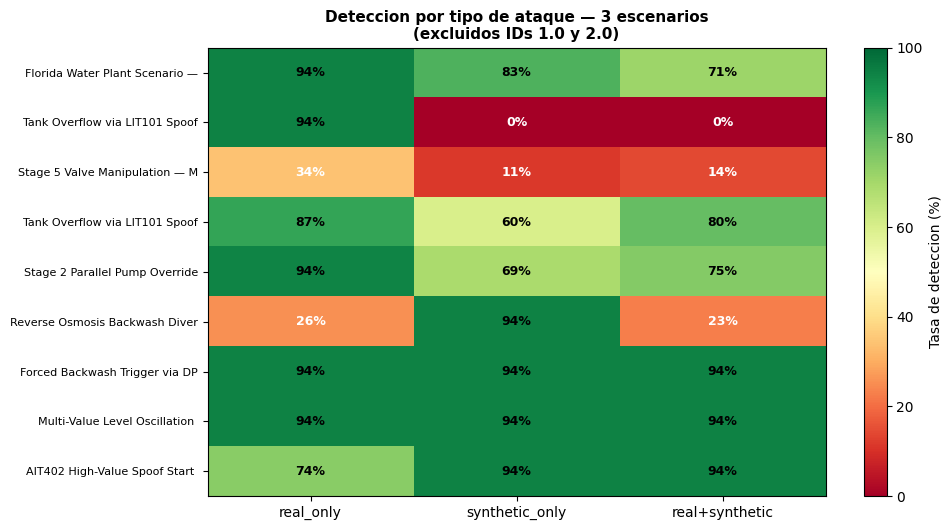

In [21]:
# Deteccion por tipo de ataque — 3 escenarios lado a lado
atk_ids_sorted = sorted(df_wins[df_wins['y']==1]['attack_id'].unique())
det_rows = []
for aid in atk_ids_sorted:
    grp = df_wins[df_wins['attack_id'] == aid]
    n_tot = len(grp)
    name  = grp['attack_name'].mode().iloc[0][:30]
    excl  = aid in EXCLUDED_IDS
    row = {'attack_id': aid, 'nombre': name, 'n_ventanas': n_tot, 'excluido': excl}
    for key in r_keys:
        sc_grp = results[key]['scores_all'][df_wins['attack_id']==aid]
        pred_g = consecutive_filter(sc_grp, results[key]['tau'], CONSEC_K)
        row[f'det_{key}'] = round(100 * pred_g.sum() / n_tot, 1) if n_tot > 0 else 0
    det_rows.append(row)

df_det = pd.DataFrame(det_rows)
print('Deteccion por tipo de ataque (%):')
print(f'{"ID":>5}  {"Nombre":32}  {"N":>5}  {"real_only":>12}  {"synth_only":>12}  {"real+synth":>12}')
print('-' * 80)
for _, row in df_det.iterrows():
    tag = '  [EXCL]' if row['excluido'] else ''
    print(f'{row["attack_id"]:>5.0f}  {row["nombre"]:32}  {row["n_ventanas"]:>5}  '
          f'{row["det_real_only"]:>11.1f}%  '
          f'{row["det_synthetic_only"]:>11.1f}%  '
          f'{row["det_real_plus_synthetic"]:>11.1f}%{tag}')

df_det.to_csv(TSTR_DIR / 'deteccion_por_tipo.csv', index=False)

# Heatmap de deteccion por tipo
df_heat = df_det[~df_det['excluido']].set_index('nombre')
heat_data = df_heat[['det_real_only','det_synthetic_only','det_real_plus_synthetic']].values

fig, ax = plt.subplots(figsize=(10, max(4, len(df_heat)*0.6)))
im = ax.imshow(heat_data, aspect='auto', cmap='RdYlGn', vmin=0, vmax=100)
ax.set_xticks([0,1,2])
ax.set_xticklabels(['real_only','synthetic_only','real+synthetic'], fontsize=10)
ax.set_yticks(range(len(df_heat)))
ax.set_yticklabels(df_heat.index.tolist(), fontsize=8)
for i in range(len(df_heat)):
    for j in range(3):
        ax.text(j, i, f'{heat_data[i,j]:.0f}%', ha='center', va='center',
                fontsize=9, fontweight='bold',
                color='white' if heat_data[i,j] < 40 else 'black')
plt.colorbar(im, ax=ax, label='Tasa de deteccion (%)')
ax.set_title('Deteccion por tipo de ataque — 3 escenarios\n(excluidos IDs 1.0 y 2.0)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(str(TSTR_DIR / 'deteccion_heatmap.png'), dpi=130, bbox_inches='tight')
plt.show()


## 13. Guardar resultados y resumen final

In [22]:
tstr_config = {
    'version'        : 'lstm_vae_tstr_v1',
    'baseline_source': 'lstm_vae_a12_baseline_v1',
    'timegan_source' : 'lstm_vae_a12_baseline_v1_v18',
    'dataset_eval'   : 'SWaT A12 Mar 2026',
    'eval_protocol'  : {
        'excluded_attack_ids': EXCLUDED_IDS,
        'consecutive_k'      : CONSEC_K,
        'tau_search'         : 'sweep 800 puntos sobre percentiles 0.5-99.5',
    },
    'training_windows': {
        'real_only'           : int(len(X_real_tr_c)),
        'synthetic_only'      : int(len(X_synth_cont)),
        'real_plus_synthetic' : int(len(X_combined_c)),
    },
    'best_epochs': {
        'real_only'           : ep_real,
        'synthetic_only'      : ep_synth,
        'real_plus_synthetic' : ep_comb,
    },
    'results': {
        key: {
            k: v for k, v in r.items()
            if k not in ('scores_all', 'sc_filt', 'y_filt', 'mask_keep')
        }
        for key, r in results.items()
    },
    'delta_vs_real_only': {
        key: {
            'delta_roc_auc'  : round(results[key]['roc_auc']   - results['real_only']['roc_auc'],   4),
            'delta_f1'       : round(results[key]['f1']        - results['real_only']['f1'],        3),
            'delta_recall'   : round(results[key]['recall']    - results['real_only']['recall'],    3),
            'delta_precision': round(results[key]['precision'] - results['real_only']['precision'], 3),
            'delta_fpr'      : round(results[key]['fpr']       - results['real_only']['fpr'],       3),
        }
        for key in ['synthetic_only', 'real_plus_synthetic']
    },
}

with open(TSTR_DIR / 'tstr_results.json', 'w') as f:
    json.dump(tstr_config, f, indent=4)

print('Artefactos guardados en:', TSTR_DIR.resolve())
for fp in sorted(TSTR_DIR.iterdir()):
    sz = fp.stat().st_size
    print(f'  {fp.name:<45} {sz/1e3:7.1f} KB')

print()
print('=' * 70)
print('RESUMEN FINAL — COMPARATIVA TSTR')
print('=' * 70)
for key in r_keys:
    r = results[key]
    print(f'  {key:<25} : AUC={r["roc_auc"]:.4f} | F1={r["f1"]:.3f} | '
          f'Rec={r["recall"]:.3f} | Prec={r["precision"]:.3f} | FPR={r["fpr"]:.3f}')
print()
print('  Mejora real+synthetic vs real_only:')
d = tstr_config['delta_vs_real_only']['real_plus_synthetic']
print(f'    ΔAUC={d["delta_roc_auc"]:+.4f} | ΔF1={d["delta_f1"]:+.3f} | '
      f'ΔRecall={d["delta_recall"]:+.3f} | ΔFPR={d["delta_fpr"]:+.3f}')
print('=' * 70)


Artefactos guardados en: D:\Documentos\Uniandes\12 Semestre\PROYECTO DE GRADO\repoPrincipal\ics-synthetic-data-augmentation\models\detectors\lstm_vae_tstr
  deteccion_heatmap.png                            79.4 KB
  deteccion_por_tipo.csv                            0.8 KB
  dist_real_vs_synth.png                           72.8 KB
  metricas_comparativas.png                       103.6 KB
  model_real_only.pt                             1917.5 KB
  model_real_plus_synthetic.pt                   1918.0 KB
  model_synthetic_only.pt                        1917.7 KB
  roc_pr_comparison.png                           132.4 KB
  score_distributions.png                          66.0 KB
  score_temporal_comparison.png                   212.2 KB
  tabla_comparativa.csv                             0.4 KB
  training_curves_comparison.png                   88.3 KB
  tstr_results.json                                 2.9 KB

RESUMEN FINAL — COMPARATIVA TSTR
  real_only                 : AUC=0.8751 | F